In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, spectrogram
from TIF import RawSignal

class EMGSignal(RawSignal):
    def __init__(self, data, sfreq, info, anotaciones, umbral_microv=50, start_time=None, end_time=None):
        """
        Clase para representar una señal de electromiografía (EMG).

        Parameters
        ----------
        data : np.ndarray
            Array 2D con la señal EMG. Forma: (n_canales, n_muestras)
        sfreq : float
            Frecuencia de muestreo en Hz.
        umbral_microv : float
            Umbral de detección de activación en microvoltios (por defecto 50).
        Start_time : float, optional
            Tiempo de inicio en segundos para recortar la señal (por defecto None, empieza desde el inicio).
        end_time : float, optional
            Tiempo de fin en segundos para recortar la señal (por defecto None, termina al final de la señal).
        """
        super().__init__(data, sfreq, info, anotaciones)
        self.data = data if data.ndim == 2 else data[np.newaxis, :]
        self.sfreq = sfreq
        self.umbral = umbral_microv
        self.start_idx = int(start_time * sfreq) if start_time is not None else 0
        self.end_idx = int(end_time * sfreq) if end_time is not None else data.shape[1]
        self.activaciones = self.detectar_activaciones()

    def detectar_activaciones(self):
        """
        Detecta índices donde la señal supera el umbral en cada canal.
        Devuelve una lista de listas (una por canal).
        """
        activaciones = []
        for canal in range(self.data.shape[0]):
            canal_data = self.data[canal]
            indices = np.where(canal_data > self.umbral)[0]
            activaciones.append(indices)
        return activaciones

    def plot_activaciones(self, canal=0):
        if canal >= self.data.shape[0]:
            raise ValueError("Índice de canal fuera de rango.")

        señal_recorte = self.data[canal, self.start_idx:self.end_idx]
        tiempo = np.arange(self.start_idx, self.end_idx) / self.sfreq

        activaciones_idx = np.array(self.activaciones[canal])
        dentro_rango = (activaciones_idx >= self.start_idx) & (activaciones_idx < self.end_idx)
        activaciones_idx_recorte = activaciones_idx[dentro_rango] - self.start_idx

        plt.figure(figsize=(12, 4))
        plt.plot(tiempo, señal_recorte, label='EMG')
        plt.plot(
            tiempo[activaciones_idx_recorte],
            señal_recorte[activaciones_idx_recorte],
            'ro', label='Activaciones detectadas'
        )
        plt.title(f'Señal EMG - Canal {canal}')
        plt.xlabel('Tiempo [s]')
        plt.ylabel('Amplitud [µV]')
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_spectrogram(self, canal=0):
        if canal >= self.data.shape[0]:
            raise ValueError("Índice de canal fuera de rango.")
        señal = self.data[canal, self.start_idx:self.end_idx]
        f, t, Sxx = spectrogram(señal, fs=self.sfreq)
        plt.figure(figsize=(10, 4))
        plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
        plt.ylabel('Frecuencia [Hz]')
        plt.xlabel('Tiempo [s]')
        plt.title(f'Espectrograma - Canal {canal}')
        plt.colorbar(label='Potencia [dB]')
        plt.tight_layout()
        plt.show()

    def plot_hilbert(self, canal=0):
        if canal >= self.data.shape[0]:
            raise ValueError("Índice de canal fuera de rango.")
        señal = self.data[canal, self.start_idx:self.end_idx]
        tiempo = np.arange(self.start_idx, self.end_idx) / self.sfreq
        envelope = np.abs(hilbert(señal))

        plt.figure(figsize=(12, 4))
        plt.plot(tiempo, señal, label='Señal EMG')
        plt.plot(tiempo, envelope, label='Envolvente (Hilbert)', linestyle='--')
        plt.title(f'Señal EMG - Canal {canal}')
        plt.xlabel('Tiempo [s]')
        plt.ylabel('Amplitud [µV]')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


In [16]:
# Cargar datos
emg_data = np.load("../4. tests/emg/emg.npy")  

In [17]:
emg_data.shape

(388971,)

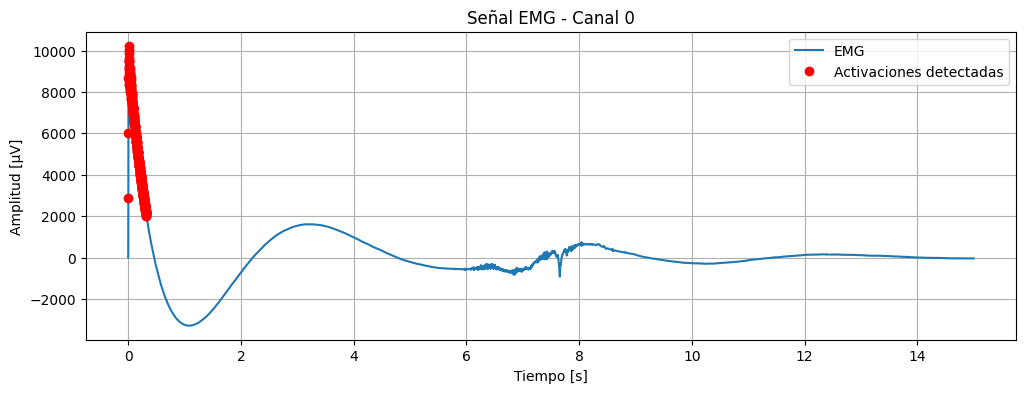

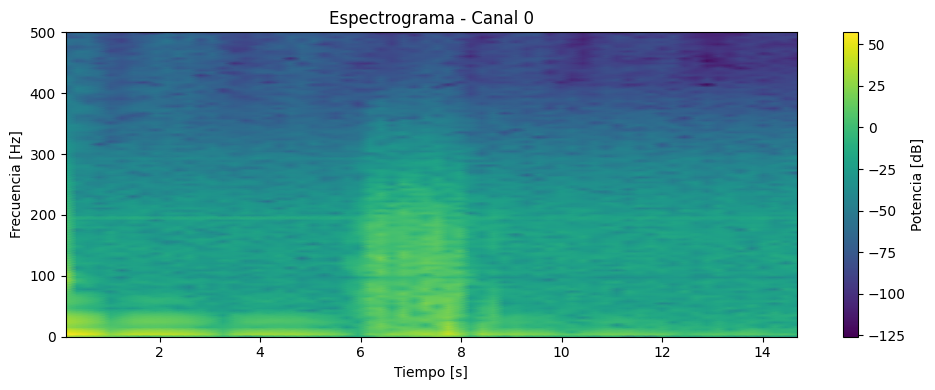

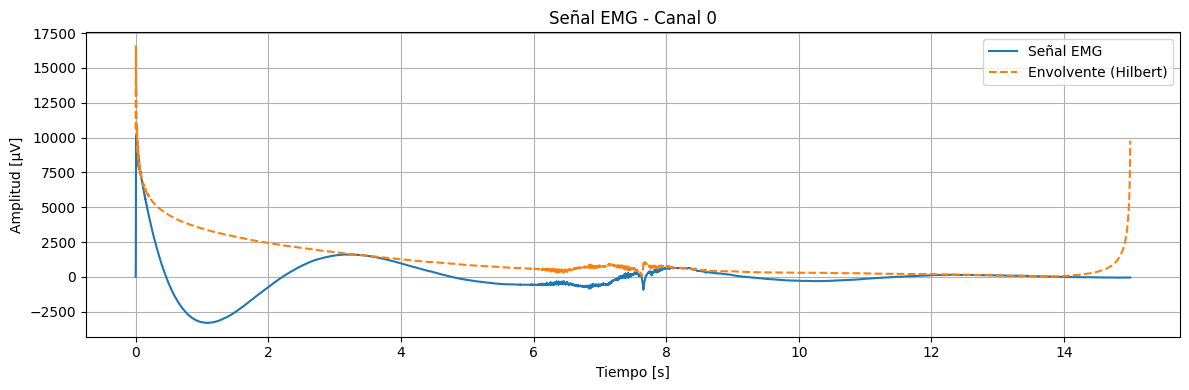

In [18]:
emg = EMGSignal(emg_data, sfreq=1000, umbral_microv=2000, start_time=0, end_time=15)

emg.plot_activaciones(canal=0)
emg.plot_spectrogram(canal=0)
emg.plot_hilbert(canal=0)
